# Visualize training metrics

This notebook loads the latest `training_metrics_*.json` in this folder and visualizes training/validation loss over steps and epochs.

Open this notebook in VSCode or Jupyter and run all cells.


In [3]:
# Section 1: Import libraries

import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
import glob
import os

sns.set_theme(style='whitegrid')

[PosixPath('output/metrics/training_metrics_20260204_034445.json'), PosixPath('output/metrics/training_metrics_20260209_151851.json')]
DataFrame shape: (1770, 14)
Available metrics: ['lr', 'train_loss', 'mask_count', 'valid_count', 'mask_ratio_actual', 'recon_error_std', 'flux_mean_avg', 'flux_std_avg', 'grad_norm', 'val_loss', 'val_loss_epoch']
Epoch summary:


,lr_mean,lr_std,train_loss_mean,train_loss_std,mask_count_mean,mask_count_std,valid_count_mean,valid_count_std,mask_ratio_actual_mean,mask_ratio_actual_std,...,flux_mean_avg_mean,flux_mean_avg_std,flux_std_avg_mean,flux_std_avg_std,grad_norm_mean,grad_norm_std,val_loss_mean,val_loss_std,val_loss_epoch_mean,val_loss_epoch_std
epoch,,,,,,,,,,,,,,,,,,,,,
0,0.000013,7.361159e-06,0.707217,0.041899,2535.732283,47.391388,8644.598425,156.070052,0.293328,0.000404,...,4.759441,8.885640,1.640995,4.310721,5.371352,0.477339,0.697680,0.015519,0.697680,0.015519
1,0.000038,7.361159e-06,0.588123,0.063998,2536.299213,51.418654,8646.543307,169.396818,0.293327,0.000425,...,4.564917,8.326345,1.567324,4.279999,4.090638,0.533702,0.597010,0.046401,0.597010,0.046401
2,0.000064,7.361159e-06,0.446312,0.044089,2536.070866,52.243657,8645.779528,173.454670,0.293328,0.000390,...,4.760279,8.484776,1.641269,4.397141,1.978194,0.531344,0.441647,0.034088,0.441647,0.034088
3,0.000089,7.270581e-06,0.393544,0.039066,2535.960630,46.385788,8645.299213,154.022020,0.293332,0.000395,...,4.759673,8.860988,1.641545,4.313663,0.894781,0.184168,0.381883,0.009191,0.381883,0.009191
4,0.000100,3.827189e-08,0.368801,0.035196,2536.125984,44.137770,8646.007874,144.583721,0.293326,0.000413,...,4.758176,9.342392,1.641290,4.719313,0.544823,0.070462,0.357309,0.006003,0.357309,0.006003
5,0.000100,1.041789e-07,0.359883,0.033225,2536.031496,45.783642,8645.637795,150.785913,0.293328,0.000403,...,4.759360,8.563112,1.641410,4.490841,0.418314,0.049297,0.342059,0.002769,0.342059,0.002769
6,0.000099,1.700886e-07,0.350206,0.037849,2535.850394,43.894730,8644.952756,144.217421,0.293330,0.000397,...,4.751942,9.660385,1.638347,4.747361,0.360257,0.055238,0.333220,0.001020,0.333220,0.001020
7,0.000099,2.352871e-07,0.344078,0.035329,2536.125984,44.935402,8645.937008,150.230233,0.293330,0.000353,...,4.758645,8.619112,1.641160,4.332846,0.340051,0.057801,0.331508,0.003868,0.331508,0.003868
8,0.000098,2.994193e-07,0.336512,0.038683,2535.606299,41.678885,8644.259843,138.475155,0.293327,0.000421,...,4.760335,8.533623,1.641378,4.301611,0.315986,0.064192,0.320359,0.005912,0.320359,0.005912


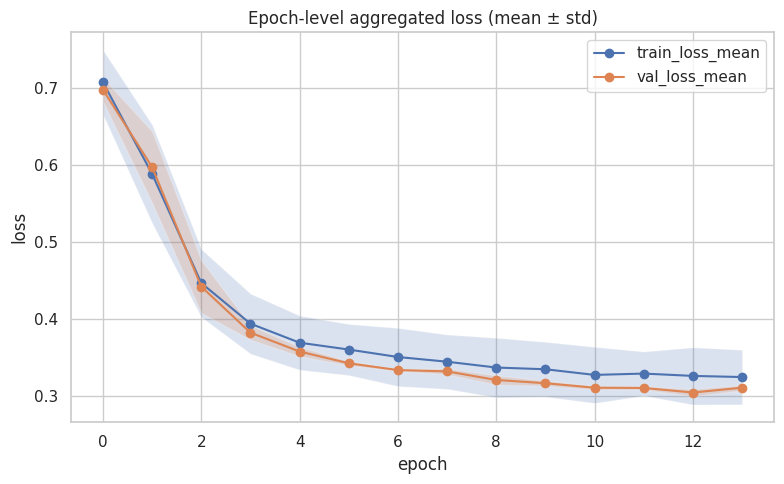

Anomaly threshold: 0.132159, found 15 anomalies


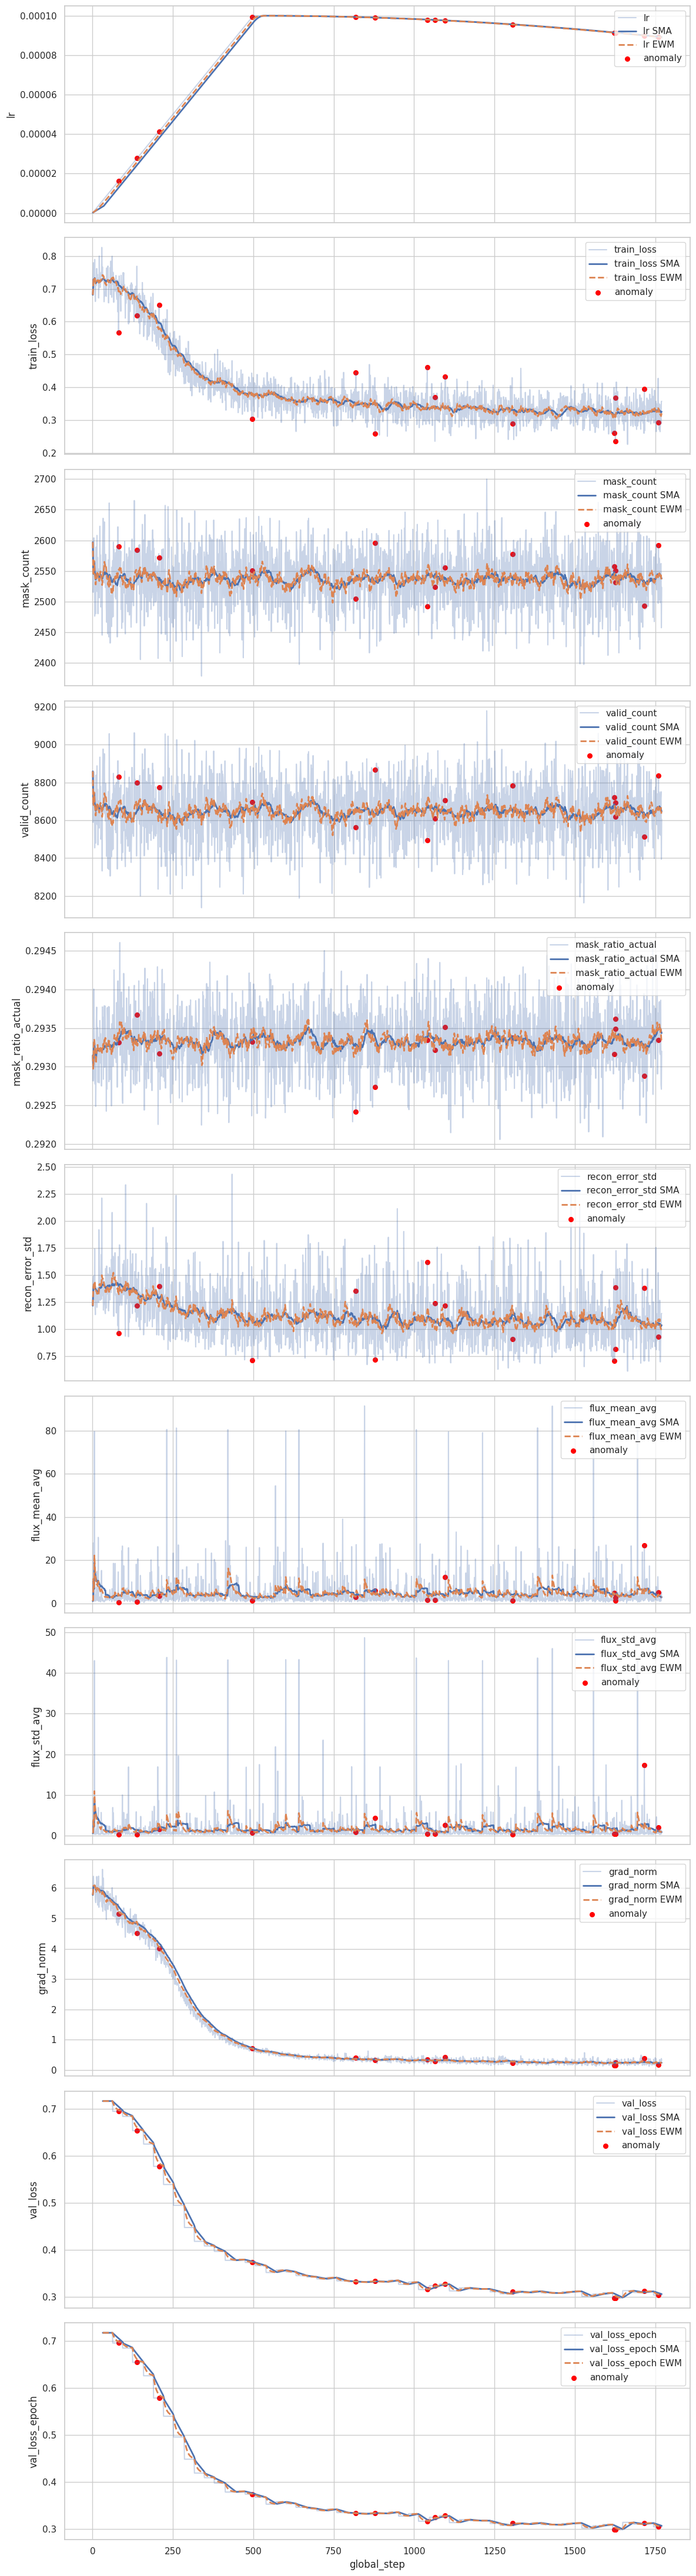

In [9]:
# Section 2: Load and parse latest metrics JSON
from read_and_plot import stat_and_plot
# Look in current directory first
p = Path('.')
files = sorted(p.glob('output/metrics/training_metrics_*.json'))

print(files)

file = files[-1]
with open(file, 'r') as f:
    data = json.load(f)

metrics_history = data.get('metrics_history', [])
stat_and_plot(metrics_history)